# 1. Drive 마운트 및 원본 데이터셋 로드


In [1]:
!pip install -q torch_geometric

import os, sys, time, math, json, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("\n[경고] GPU 런타임이 아니다. 런타임 > 런타임 유형 변경 > T4 GPU 로 바꿀 것.")

from google.colab import drive
drive.mount('/content/drive')

DRIVE     = '/content/drive/MyDrive/ACK2026_Wafer'
RAW_PKL   = f'{DRIVE}/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl'
LOCAL_NPZ = '/content/wafer_graph.npz'
DRIVE_NPZ = f'{DRIVE}/Train_Model/Training_Data/wafer_graph.npz'
CACHE_DIR = f'{DRIVE}/Train_Model/graph_results'     # 모델별 결과 저장 -> 끊겨도 이어서
os.makedirs(os.path.dirname(DRIVE_NPZ), exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

assert os.path.exists(RAW_PKL), f"원본 pkl 을 찾을 수 없다: {RAW_PKL}"
df_raw = pd.read_pickle(RAW_PKL)
print(f"\n원본 로드 완료: {len(df_raw):,}장")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.2 MB/s eta 0:00:00
torch 2.11.0+cu128 | CUDA: True
Mounted at /content/drive

원본 로드 완료: 25,519장


# 2. 웨이퍼 전처리 함수 선언

웨이퍼 1장 → 그래프(노드 11차원 + k-NN 엣지) + 스칼라 4개.


In [2]:
"""WM-811K 웨이퍼 맵 전처리 v2.

v1(`Data_Preprocessing/Wafer Data Preprocessing6.ipynb`) 대비 변경점

1. 노이즈 필터를 '다이 피치' 단위로 재정의하고, 삭제 대신 플래그로 보존
   - v1: eps=0.10 (정규화 좌표) -> 웨이퍼 크기에 따라 실제 반경이 1.3~8.6 다이로 요동.
     Center 60%, Scratch 59%, Loc 51% 의 결함 다이가 삭제되고 있었음.
   - v2: DBSCAN 을 다이(die) 단위 좌표에서 수행하여 eps 가 항상 동일한 물리적 거리.
     노이즈로 판정된 점도 지우지 않고 `is_noise` 특징/채널로 남김.

2. 유효 다이(waferMap > 0) 기준 반경 정규화
   - v1: rmax = max(w, h) / 2 로 x, y 를 동시에 나눔 -> 종횡비가 다른 웨이퍼(전체의 66%)
     에서 원이 타원으로 왜곡. 최외곽 반경이 웨이퍼마다 0.955~1.037 로 흔들림.
   - v2: 중심 = 유효 다이 무게중심, R = 유효 다이의 최대 반경.
     정의상 모든 결함 다이가 r <= 1 이 되어 클리핑 손실이 0.

3. 극좌표 이미지를 3채널 밀도 맵으로 교체
   - ch0 결함 밀도 = (빈 내 결함 다이 수) / (빈 내 유효 다이 수)
   - ch1 유효 다이 마스크 = 그 위치에 웨이퍼가 존재하는가
   - ch2 노이즈 판정 결함 밀도
   - v1 은 1채널 이진 대입(`= 1.0`)이라 Edge-Ring 결함의 19% 가 같은 픽셀에 겹쳐 소실됐고,
     "결함 없음"과 "다이 없음"을 구분할 수 없었음.

5. GCN 입력 강화
   - 반경 기반 그래프 대신 k-NN 그래프(k 고정) -> 평균 차수가 0.38~73.8 로 벌어지던 문제 해소.
   - 노드 특징을 (x, y) 2차원에서 11차원으로 확장.

주의: 전처리는 라벨(failureType)을 일절 사용하지 않는다. 패턴별로 파라미터를 다르게 주면
추론 시점에 재현할 수 없는 라벨 누수가 된다.
"""


import numpy as np
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

# 8대 불량 패턴 라벨 인코딩. 전처리·데이터셋·학습이 공유하므로 여기 한 곳에만 둔다.
LABEL_MAP = {
    "Center": 0, "Donut": 1, "Edge-Loc": 2, "Edge-Ring": 3,
    "Loc": 4, "Random": 5, "Scratch": 6, "Near-full": 7,
}
REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

# 노드 특징 벡터의 열 인덱스. 증강(회전/반전)이 이 순서에 의존하므로 변경 시 주의.
FEAT_X, FEAT_Y = 0, 1          # 회전/반전 대상
FEAT_R = 2
FEAT_COS, FEAT_SIN = 3, 4      # 회전/반전 대상
FEAT_DENS2 = 5
FEAT_DENS4 = 6
FEAT_KNN_DIST = 7
FEAT_LOCAL_RATIO = 8
FEAT_IS_NOISE = 9
FEAT_LOG_N = 10
NUM_NODE_FEATURES = 11

# 그래프 수준 스칼라 (분류기에 직접 주입)
NUM_GRAPH_SCALARS = 4

POLAR_CHANNELS = 3


class WaferPreprocessorV2:
    """웨이퍼 맵 한 장을 (그래프, 극좌표 이미지, 스칼라) 3종 표현으로 변환한다.

    Parameters
    ----------
    r_bins, theta_bins : 극좌표 이미지 해상도.
    knn_k : 각 결함 노드가 연결할 최근접 이웃 수. 방향성 엣지로 저장하고 학습 시 대칭화한다.
    noise_eps_dies : DBSCAN 반경. **다이 개수 단위**라 웨이퍼 크기와 무관하게 일정하다.
    noise_min_samples : DBSCAN 최소 샘플 수.
    drop_noise : True 면 노이즈 판정 결함을 실제로 삭제한다. 기본 False(플래그만 부여).
        Random 패턴은 산발 노이즈 자체가 클래스 정의이고 Scratch 는 폭 1~2 다이의 선이라
        삭제하면 신호가 사라진다. 삭제 대신 모델이 판단하도록 정보만 넘긴다.
    density_radii : 국소 밀도 특징을 계산할 반경(다이 단위).
    """

    def __init__(
        self,
        r_bins: int = 64,
        theta_bins: int = 64,
        knn_k: int = 8,
        noise_eps_dies: float = 2.0,
        noise_min_samples: int = 3,
        drop_noise: bool = False,
        density_radii: tuple[float, float] = (2.0, 4.0),
        include_polar: bool = True,
    ):
        self.r_bins = r_bins
        self.theta_bins = theta_bins
        self.knn_k = knn_k
        self.noise_eps_dies = noise_eps_dies
        self.noise_min_samples = noise_min_samples
        self.drop_noise = drop_noise
        self.density_radii = density_radii
        # 순수 graph 모델(GCN/GraphSAGE/GAT ...)만 비교할 때는 극좌표 이미지가 필요 없다.
        # 끄면 저장 용량과 RAM 이 크게 줄고 전처리도 빨라진다.
        # theta_bins 는 이미지가 없어도 증강 회전 단위로 계속 쓰이므로 그대로 둔다.
        self.include_polar = include_polar

    # ------------------------------------------------------------------
    # [개선 2] 웨이퍼 기하 구조 추정
    # ------------------------------------------------------------------
    @staticmethod
    def wafer_geometry(wafer_map: np.ndarray):
        """유효 다이만으로 웨이퍼 원의 중심과 반경을 추정한다.

        배열 중심 `(w/2, h/2)` 과 `max(w, h)/2` 를 쓰던 v1 과 달리 종횡비, 여백,
        다이 크기에 영향받지 않는다. 반환하는 R 은 유효 다이의 최대 반경이므로
        모든 유효 다이(=결함 다이 포함)가 r <= 1 을 만족한다.
        """
        vy, vx = np.nonzero(wafer_map > 0)
        if len(vx) == 0:
            return None
        cx, cy = vx.mean(), vy.mean()
        dv = np.hypot(vx - cx, vy - cy)
        radius = float(dv.max())
        if radius <= 0:
            return None
        return vx, vy, cx, cy, radius

    # ------------------------------------------------------------------
    def process_wafer(self, wafer_map: np.ndarray) -> dict | None:
        wafer_map = np.asarray(wafer_map)
        geom = self.wafer_geometry(wafer_map)
        if geom is None:
            return None
        vx, vy, cx, cy, radius = geom

        by, bx = np.nonzero(wafer_map == 2)
        if len(bx) == 0:
            return None

        # 다이 단위 좌표(1 = 다이 1개 간격). 거리 기반 파라미터는 전부 이 좌표계에서 정의한다.
        defect_px = np.column_stack((bx - cx, cy - by)).astype(np.float64)
        die_px = np.column_stack((vx - cx, cy - vy)).astype(np.float64)

        # [개선 1] 다이 단위 DBSCAN -> 웨이퍼 크기와 무관하게 동일한 물리적 필터
        if len(defect_px) >= self.noise_min_samples:
            labels = DBSCAN(
                eps=self.noise_eps_dies, min_samples=self.noise_min_samples
            ).fit(defect_px).labels_
            is_noise = (labels == -1)
        else:
            is_noise = np.ones(len(defect_px), dtype=bool)

        if self.drop_noise and (~is_noise).sum() >= 3:
            defect_px = defect_px[~is_noise]
            is_noise = is_noise[~is_noise]

        node_feat = self._node_features(defect_px, die_px, radius, is_noise)
        edge_index = self._knn_edges(defect_px)
        scalars = np.array(
            [
                np.log1p(len(defect_px)) / 10.0,
                len(defect_px) / len(die_px),
                np.log1p(len(die_px)) / 10.0,
                radius / 100.0,
            ],
            dtype=np.float32,
        )

        result = {
            "node_feat": node_feat.astype(np.float16),
            "edge_index": edge_index.astype(np.int16),  # 노드 수 < 32767 보장
            "scalars": scalars,
            "n_defect": int(len(defect_px)),
            "n_die": int(len(die_px)),
            "radius": float(radius),
            "noise_ratio": float(is_noise.mean()),
        }
        if self.include_polar:
            result["polar"] = self._polar_density(
                defect_px, die_px, radius, is_noise).astype(np.float16)
        return result

    # ------------------------------------------------------------------
    # [개선 5] 노드 특징 11차원
    # ------------------------------------------------------------------
    def _node_features(self, defect_px, die_px, radius, is_noise) -> np.ndarray:
        n = len(defect_px)
        x = defect_px[:, 0] / radius
        y = defect_px[:, 1] / radius
        r = np.hypot(x, y)
        theta = np.arctan2(y, x)

        defect_tree = cKDTree(defect_px)
        die_tree = cKDTree(die_px)

        r_small, r_large = self.density_radii
        # 자기 자신이 항상 포함되므로 -1
        dens_small = np.array(defect_tree.query_ball_point(defect_px, r_small, return_length=True)) - 1.0
        dens_large = np.array(defect_tree.query_ball_point(defect_px, r_large, return_length=True)) - 1.0
        die_large = np.array(die_tree.query_ball_point(defect_px, r_large, return_length=True))

        # k-NN 평균 거리(다이 단위). 노드가 k+1개 미만이면 있는 만큼만 사용한다.
        k = min(self.knn_k + 1, n)
        if k >= 2:
            dists, _ = defect_tree.query(defect_px, k=k)
            knn_mean = dists[:, 1:].mean(axis=1)
        else:
            knn_mean = np.full(n, 10.0)

        feat = np.zeros((n, NUM_NODE_FEATURES), dtype=np.float32)
        feat[:, FEAT_X] = x
        feat[:, FEAT_Y] = y
        feat[:, FEAT_R] = r
        feat[:, FEAT_COS] = np.cos(theta)
        feat[:, FEAT_SIN] = np.sin(theta)
        feat[:, FEAT_DENS2] = np.log1p(np.clip(dens_small, 0, None))
        feat[:, FEAT_DENS4] = np.log1p(np.clip(dens_large, 0, None))
        feat[:, FEAT_KNN_DIST] = np.clip(knn_mean, 0, 20.0) / 20.0
        feat[:, FEAT_LOCAL_RATIO] = np.clip(dens_large, 0, None) / np.maximum(die_large, 1.0)
        feat[:, FEAT_IS_NOISE] = is_noise.astype(np.float32)
        feat[:, FEAT_LOG_N] = np.log1p(n) / 10.0
        return feat

    # ------------------------------------------------------------------
    # [개선 5] 고정 반경 대신 k-NN 그래프
    # ------------------------------------------------------------------
    def _knn_edges(self, defect_px) -> np.ndarray:
        n = len(defect_px)
        k = min(self.knn_k + 1, n)
        if k < 2:
            return np.zeros((2, 0), dtype=np.int64)
        _, idx = cKDTree(defect_px).query(defect_px, k=k)
        src = np.repeat(np.arange(n), k - 1)
        dst = idx[:, 1:].reshape(-1)
        return np.vstack((src, dst))

    # ------------------------------------------------------------------
    # [개선 3] 3채널 극좌표 밀도 맵
    # ------------------------------------------------------------------
    def _bin_indices(self, pts, radius):
        r = np.hypot(pts[:, 0], pts[:, 1]) / radius
        theta = np.arctan2(pts[:, 1], pts[:, 0])
        ri = np.clip((r * self.r_bins).astype(np.int64), 0, self.r_bins - 1)
        # v1 은 (theta_bins - 1) 을 곱해 마지막 빈이 theta == +pi 한 점만 받았다.
        # theta_bins 를 곱하고 modulo 를 취해야 각 빈의 각도 폭이 균일해진다.
        u = (theta + np.pi) / (2 * np.pi) * self.theta_bins
        # +0.5 후 내림 = 반올림. 빈 k 의 '중심'이 theta = -pi + k*2pi/T 에 놓인다.
        # 내림만 쓰면 빈 경계가 theta = 0, +-pi/2, +-pi 위에 정확히 얹히는데,
        # 격자 좌표의 결함은 이 축 위에 대량으로 존재해서 좌우 반전 시
        # 그래프 트랙과 이미지 트랙이 반 칸 어긋난다(축 위 점은 반전의 고정점이어야 함).
        ti = np.floor(u + 0.5).astype(np.int64) % self.theta_bins
        return ri * self.theta_bins + ti

    def _polar_density(self, defect_px, die_px, radius, is_noise) -> np.ndarray:
        size = self.r_bins * self.theta_bins
        die_count = np.bincount(self._bin_indices(die_px, radius), minlength=size)
        defect_bins = self._bin_indices(defect_px, radius)
        defect_count = np.bincount(defect_bins, minlength=size)
        noise_count = np.bincount(defect_bins[is_noise], minlength=size)

        polar = np.zeros((POLAR_CHANNELS, size), dtype=np.float32)
        denom = np.maximum(die_count, 1)
        polar[0] = defect_count / denom          # 결함 밀도
        polar[1] = (die_count > 0).astype(np.float32)  # 유효 다이 마스크
        polar[2] = noise_count / denom           # 노이즈 판정 결함 밀도
        return polar.reshape(POLAR_CHANNELS, self.r_bins, self.theta_bins)


# 3. 전처리 완료 데이터셋 생성 함수 선언

25519장을 처리해 packed `.npz` 하나로 묶는다.


In [3]:
"""WM811K_defects.pkl -> 학습용 packed .npz 생성 스크립트.

사용 예)
    python src/build_dataset.py \
        --input  /content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl \
        --output /content/drive/MyDrive/ACK2026_Wafer/Train_Model/Training_Data/wafer_v2.npz

가변 길이인 노드/엣지를 하나의 큰 배열 + 오프셋(ptr)으로 묶어 저장한다.
웨이퍼마다 개별 dict 를 피클하던 v1 방식보다 로딩이 빠르고 RAM 을 적게 쓴다.
"""


import argparse
import time

import numpy as np
import pandas as pd



def flatten_label(value):
    """MATLAB 유래의 중첩 배열(['Edge-Ring'] 등)을 문자열로 편다."""
    while isinstance(value, (list, np.ndarray)) and len(value) > 0:
        value = value[0]
    return value




def build_dataset(input_pkl, output_npz, r_bins=64, theta_bins=64, knn_k=8,
                  noise_eps_dies=2.0, noise_min_samples=3, drop_noise=False, limit=0,
                  include_polar=True):
    """원본 pkl 을 읽어 packed .npz 로 저장한다. 노트북에서도 그대로 호출할 수 있다.

    include_polar=False 면 극좌표 이미지를 만들지도 저장하지도 않는다.
    순수 graph 모델만 비교할 때 쓰면 파일이 훨씬 작아지고 전처리도 빨라진다.
    """
    df = pd.read_pickle(input_pkl)
    if limit:
        df = df.iloc[:limit]
    df = df.reset_index(drop=True)  # v1 은 인덱스를 리셋하지 않아 진행률 출력이 깨졌다
    labels_str = df["failureType"].map(flatten_label)
    lot_codes = pd.factorize(df["lotName"].map(flatten_label).astype(str))[0]

    pp = WaferPreprocessorV2(
        r_bins=r_bins, theta_bins=theta_bins, knn_k=knn_k,
        noise_eps_dies=noise_eps_dies, noise_min_samples=noise_min_samples,
        drop_noise=drop_noise, include_polar=include_polar,
    )

    feats, edges, polars, scalars, labels, lots = [], [], [], [], [], []
    skipped = 0
    t0 = time.time()
    for i, wafer_map in enumerate(df["waferMap"]):
        label = labels_str.iloc[i]
        if label not in LABEL_MAP:
            skipped += 1
            continue
        out = pp.process_wafer(wafer_map)
        if out is None:
            skipped += 1
            continue
        feats.append(out["node_feat"])
        edges.append(out["edge_index"])
        if include_polar:
            polars.append(out["polar"])
        scalars.append(out["scalars"])
        labels.append(LABEL_MAP[label])
        lots.append(lot_codes[i])
        if (i + 1) % 2000 == 0:
            print(f"  {i + 1}/{len(df)}  ({time.time() - t0:.0f}s)", flush=True)

    node_ptr = np.concatenate([[0], np.cumsum([len(f) for f in feats])]).astype(np.int64)
    edge_ptr = np.concatenate([[0], np.cumsum([e.shape[1] for e in edges])]).astype(np.int64)

    arrays = dict(
        node_feat=np.concatenate(feats, axis=0),
        node_ptr=node_ptr,
        edge_index=np.concatenate(edges, axis=1) if edges else np.zeros((2, 0), np.int16),
        edge_ptr=edge_ptr,
        scalars=np.stack(scalars),
        labels=np.array(labels, dtype=np.int64),
        lot_ids=np.array(lots, dtype=np.int64),
        theta_bins=theta_bins,
        r_bins=r_bins,
    )
    if include_polar:
        arrays["polar"] = np.stack(polars)
    np.savez_compressed(output_npz, **arrays)

    n = len(labels)
    print(f"\n완료: {n}개 저장, {skipped}개 제외, {time.time() - t0:.0f}s")
    print(f"평균 노드 수 {node_ptr[-1] / n:.1f}, 평균 방향성 엣지 수 {edge_ptr[-1] / n:.1f}")
    print(f"극좌표 이미지: {'포함' if include_polar else '미포함(graph 전용)'}")
    print(f"-> {output_npz}")
    return output_npz


# 4. 전처리 과정 실행

`include_polar=False` 라 극좌표 이미지를 만들지 않는다(순수 graph 모델에는 불필요).


In [4]:
build_dataset(RAW_PKL, LOCAL_NPZ,
              knn_k=8,                 # 결함 노드가 연결할 최근접 이웃 수
              noise_eps_dies=2.0,      # DBSCAN 반경 (다이 단위 -> 웨이퍼 크기와 무관)
              noise_min_samples=3,
              include_polar=False)

!cp "$LOCAL_NPZ" "$DRIVE_NPZ"
print("Drive 백업 완료:", DRIVE_NPZ)


  2000/25519  (20s)
  4000/25519  (30s)
  6000/25519  (43s)
  8000/25519  (54s)
  10000/25519  (70s)
  12000/25519  (83s)
  14000/25519  (94s)
  16000/25519  (102s)
  18000/25519  (112s)
  20000/25519  (119s)
  22000/25519  (130s)
  24000/25519  (139s)

완료: 25519개 저장, 0개 제외, 158s
평균 노드 수 240.0, 평균 방향성 엣지 수 1920.4
극좌표 이미지: 미포함(graph 전용)
-> /content/wafer_graph.npz
Drive 백업 완료: /content/drive/MyDrive/ACK2026_Wafer/Train_Model/Training_Data/wafer_graph.npz


# 5. 증강 관련 함수 선언

**on-the-fly 증강** — 학습 데이터를 꺼낼 때마다 무작위 회전(64가지) + 50% 확률 뒤집기를
적용한다. 장수는 늘지 않고 다양성만 늘어난다. 검증/테스트에는 `augment=False` 로 강제된다.


In [5]:
"""전처리 결과를 PyG 데이터로 공급하는 Dataset + 회전/반전 증강.

[개선 4] 데이터 증강
웨이퍼 결함 라벨은 웨이퍼를 돌리거나 뒤집어도 바뀌지 않는다
(Center/Donut/Edge-Ring/Random/Near-full 은 회전 불변, Loc/Edge-Loc/Scratch 도
반경 위치와 형태가 유지되므로 라벨이 보존된다).
극좌표 표현에서 회전은 theta 축 순환 시프트 한 줄이라 비용이 사실상 0이다.

중요: 그래프 트랙과 이미지 트랙에 **동일한** 변환을 적용해야 한다.
서로 다른 각도로 회전하면 두 트랙이 모순된 정보를 주게 되어 융합이 망가진다.
"""


import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected



class PackedWaferData:
    """`build_dataset.py` 가 만든 .npz 를 메모리에 올린다.

    노드/엣지는 가변 길이라 하나의 큰 배열 + 오프셋(ptr) 형태로 저장한다.
    float16 / int16 로 보관하고 꺼낼 때만 캐스팅해 RAM 사용량을 4분의 1로 줄인다.
    """

    def __init__(self, npz_path: str):
        z = np.load(npz_path, allow_pickle=False)
        self.node_feat = z["node_feat"]      # [총 노드 수, F] float16
        self.node_ptr = z["node_ptr"]        # [N+1]
        self.edge_index = z["edge_index"]    # [2, 총 엣지 수] int16 (그래프 로컬 인덱스)
        self.edge_ptr = z["edge_ptr"]        # [N+1]
        # graph 전용 npz(build_dataset(..., include_polar=False))에는 polar 가 없다.
        self.polar = z["polar"] if "polar" in z.files else None
        self.scalars = z["scalars"]          # [N, S] float32
        self.labels = z["labels"]            # [N] int64
        self.lot_ids = z["lot_ids"]          # [N] int64 (lot 단위 분할용)
        self.theta_bins = int(z["theta_bins"])

    def __len__(self):
        return len(self.labels)

    def get(self, i: int):
        ns, ne = self.node_ptr[i], self.node_ptr[i + 1]
        es, ee = self.edge_ptr[i], self.edge_ptr[i + 1]
        polar = (torch.from_numpy(self.polar[i].astype(np.float32))
                 if self.polar is not None else None)
        return (
            torch.from_numpy(self.node_feat[ns:ne].astype(np.float32)),
            torch.from_numpy(self.edge_index[:, es:ee].astype(np.int64)),
            polar,
            torch.from_numpy(self.scalars[i]),
            int(self.labels[i]),
        )


class WaferDualTrackDataset(torch.utils.data.Dataset):
    """PyG `Data` 를 돌려주는 Dataset. `augment=True` 일 때만 증강한다.

    Parameters
    ----------
    augment : 학습 세트에만 True. 검증/테스트에는 반드시 False.
    rotate : theta 빈 단위 무작위 회전.
    flip : 무작위 좌우 반전(거울상).
    """

    def __init__(self, packed: PackedWaferData, indices, augment=False,
                 rotate=True, flip=True, seed=0):
        self.packed = packed
        self.indices = np.asarray(indices)
        self.augment = augment
        self.rotate = rotate
        self.flip = flip
        self.theta_bins = packed.theta_bins
        self._rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, edge_index, polar, scalars, y = self.packed.get(self.indices[i])

        if self.augment:
            if self.flip and self._rng.random() < 0.5:
                x, polar = _apply_flip(x, polar)
            if self.rotate:
                shift = int(self._rng.integers(0, self.theta_bins))
                if shift:
                    x, polar = _apply_rotation(x, polar, shift, self.theta_bins)

        # 저장은 방향성 k-NN 엣지로 하고, 여기서 대칭화한다(중복 제거 포함).
        if edge_index.numel():
            edge_index = to_undirected(edge_index, num_nodes=x.size(0))

        data = Data(
            x=x,
            edge_index=edge_index,
            scalars=scalars.unsqueeze(0),      # [1, S] -> [B, S]
            y=torch.tensor([y], dtype=torch.long),
        )
        if polar is not None:
            data.polar = polar.unsqueeze(0)    # [1, C, R, T] -> 배치 시 [B, C, R, T]
        return data


# ----------------------------------------------------------------------
# 증강 연산: 두 트랙이 정확히 같은 변환을 받도록 한 곳에서 정의한다.
# ----------------------------------------------------------------------
def _apply_rotation(x: torch.Tensor, polar: torch.Tensor | None, shift: int, theta_bins: int):
    """theta 축으로 `shift` 빈 회전.

    극좌표 인덱스가 ti = ((theta + pi) / 2pi * T) % T 이므로 점을
    +phi 만큼 돌리면 ti -> ti + shift 가 된다. 이는 torch.roll 과 정확히 일치한다.

    polar 가 None(graph 전용 데이터)이면 그래프 쪽만 회전한다.
    """
    phi = 2.0 * np.pi * shift / theta_bins
    c, s = np.cos(phi), np.sin(phi)
    x = x.clone()
    px, py = x[:, FEAT_X].clone(), x[:, FEAT_Y].clone()
    x[:, FEAT_X] = c * px - s * py
    x[:, FEAT_Y] = s * px + c * py
    cx, sy = x[:, FEAT_COS].clone(), x[:, FEAT_SIN].clone()
    x[:, FEAT_COS] = c * cx - s * sy
    x[:, FEAT_SIN] = s * cx + c * sy
    if polar is None:
        return x, None
    return x, torch.roll(polar, shifts=shift, dims=-1)


def _apply_flip(x: torch.Tensor, polar: torch.Tensor | None):
    """y -> -y 거울상. 극좌표에서는 theta -> -theta.

    u = (theta + pi) / 2pi * T 이고 비닝이 round(u) 이므로 반전 후에는
    round(T - u) = T - round(u), 즉 ti -> (-ti) % T 가 된다.
    torch.flip 은 i -> T-1-i 이라 한 칸 모자라므로 roll(+1) 로 보정한다.
    """
    x = x.clone()
    x[:, FEAT_Y] = -x[:, FEAT_Y]
    x[:, FEAT_SIN] = -x[:, FEAT_SIN]
    if polar is None:
        return x, None
    return x, torch.roll(torch.flip(polar, dims=[-1]), shifts=1, dims=-1)


# ----------------------------------------------------------------------
# 학습 코드에 바로 물릴 수 있는 로더 구성 헬퍼.
# 모델은 포함하지 않는다 -- 어떤 graph 모델이든 이 로더를 그대로 받아 쓰면 된다.
# ----------------------------------------------------------------------
def make_splits(labels, lot_ids, mode="stratified", holdout_test=False, seed=42):
    """(train, val, test) 인덱스를 만든다.

    mode="stratified" : v1 과 동일한 무작위 층화 분할. 같은 lot 이 양쪽에 섞인다.
    mode="lot"        : 같은 lot 은 train/val/test 중 한 곳에만. 누수가 사라진다.
    holdout_test=False: test = val (v1 호환). True 면 70/15/15 3분할.
    """
    from sklearn.model_selection import GroupShuffleSplit, train_test_split

    idx = np.arange(len(labels))

    def split(indices, frac):
        if mode == "lot":
            gss = GroupShuffleSplit(n_splits=1, test_size=frac, random_state=seed)
            a, b = next(gss.split(indices, labels[indices], lot_ids[indices]))
        else:
            a, b = train_test_split(np.arange(len(indices)), test_size=frac,
                                    stratify=labels[indices], random_state=seed)
        return indices[a], indices[b]

    if not holdout_test:
        train_idx, val_idx = split(idx, 0.2)
        return train_idx, val_idx, val_idx
    train_idx, rest = split(idx, 0.3)
    val_idx, test_idx = split(rest, 0.5)
    return train_idx, val_idx, test_idx


def _worker_init(worker_id):
    """DataLoader 워커마다 증강 RNG 를 다시 뿌린다(안 하면 모든 워커가 같은 난수를 쓴다)."""
    info = torch.utils.data.get_worker_info()
    info.dataset._rng = np.random.default_rng(torch.initial_seed() % (2**32))


def make_loaders(npz_path, batch_size=64, augment=True, split="stratified",
                 holdout_test=False, seed=42, num_workers=2):
    """npz 하나로 (train_loader, val_loader, test_loader, packed) 를 만든다.

    증강은 train 에만 걸린다. val/test 에 증강이 들어가면 채점 문제 자체가 바뀐다.

    사용 예)
        tr, va, te, packed = make_loaders("wafer_graph.npz")
        model = MyGraphNet(in_dim=NUM_NODE_FEATURES, num_classes=8)
        for batch in tr:
            out = model(batch.x, batch.edge_index, batch.batch)
    """
    from torch_geometric.loader import DataLoader

    packed = PackedWaferData(npz_path)
    train_idx, val_idx, test_idx = make_splits(
        packed.labels, packed.lot_ids, split, holdout_test, seed)

    train_set = WaferDualTrackDataset(packed, train_idx, augment=augment, seed=seed)
    val_set = WaferDualTrackDataset(packed, val_idx, augment=False)
    test_set = WaferDualTrackDataset(packed, test_idx, augment=False)

    common = dict(num_workers=num_workers, persistent_workers=num_workers > 0)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              worker_init_fn=_worker_init if num_workers else None, **common)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, **common)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, **common)
    print(f"train {len(train_idx)} / val {len(val_idx)} / test {len(test_idx)}"
          f"  (분할: {split}, 증강: {augment}, 극좌표: {packed.polar is not None})")
    return train_loader, val_loader, test_loader, packed


def class_weights(labels, num_classes=8):
    """sklearn 의 'balanced' 와 같은 식. 클래스가 빠져도 길이를 항상 보장한다."""
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    return np.where(counts > 0, len(labels) / (num_classes * np.maximum(counts, 1)), 0.0)


# 6. 증강 테스트 함수 선언 및 실행

회전 후 **노드 좌표로 다시 계산한** 각도가 기대값과 맞는지 200장 전수 검사한다.
**`0개 실패` 가 나와야 다음으로 넘어간다.**


In [6]:
"""증강 정합성 검증.

회전/반전은 그래프 트랙과 이미지 트랙에 **똑같이** 적용돼야 한다. 어긋나면 두 트랙이
모순된 정보를 주게 되어 융합 성능이 오히려 떨어진다. 여기서 검증하는 것:

1. 회전 후 노드 좌표로 다시 계산한 theta 빈 == torch.roll 로 이동한 빈
2. 반전 후에도 동일
3. 회전/반전이 반경 r 과 노드 개수를 보존
4. cos/sin 특징이 회전 후에도 (x, y) 와 일치

실행: python src/test_augmentation.py <WM811K_defects.pkl>
"""


import sys

import numpy as np
import torch


T = 64


def theta_bin(x, y):
    """wafer_preprocessing._bin_indices 와 동일한 theta 비닝."""
    theta = np.arctan2(y, x)
    return np.floor((theta + np.pi) / (2 * np.pi) * T + 0.5).astype(np.int64) % T


def bin_gap(a, b):
    """두 theta 빈 사이의 순환 거리(칸 수)."""
    d = np.abs(a - b) % T
    return np.minimum(d, T - d)


def check(wafer_map, pp):
    out = pp.process_wafer(wafer_map)
    if out is None:
        return None
    x = torch.from_numpy(out["node_feat"].astype(np.float32))
    polar = torch.from_numpy(out["polar"].astype(np.float32))
    base_bin = theta_bin(x[:, FEAT_X].numpy(), x[:, FEAT_Y].numpy())
    # 웨이퍼 정중앙(r = 0)의 노드는 각도가 정의되지 않아 회전에 불변이다. 비교에서 제외.
    has_angle = x[:, FEAT_R].numpy() > 1e-3
    errs = []

    for shift in (1, 7, 16, 33, 63):
        xr, pr = _apply_rotation(x, polar, shift, T)
        got = theta_bin(xr[:, FEAT_X].numpy(), xr[:, FEAT_Y].numpy())
        want = (base_bin + shift) % T
        # node_feat 이 float16 이라 빈 경계에서 ±1 칸까지는 허용한다.
        # 2칸 이상 벌어지면 변환 자체가 틀린 것이다.
        gap = bin_gap(got, want)[has_angle]
        if gap.max() > 1:
            errs.append(f"rot{shift}: theta 빈 최대 {gap.max()}칸 어긋남")
        elif (gap > 0).mean() > 0.02:
            errs.append(f"rot{shift}: 경계 오차 과다 {(gap > 0).mean():.3f}")
        if not torch.allclose(pr, torch.roll(polar, shift, dims=-1)):
            errs.append(f"rot{shift}: polar roll 불일치")
        if not torch.allclose(xr[:, FEAT_R], x[:, FEAT_R], atol=1e-5):
            errs.append(f"rot{shift}: 반경이 변함")
        # cos/sin 이 회전 후 좌표와 여전히 일치하는가
        r = xr[:, FEAT_R].clamp(min=1e-6)
        if not torch.allclose(xr[:, FEAT_COS] * r, xr[:, FEAT_X], atol=1e-3):
            errs.append(f"rot{shift}: cos 특징 불일치")
        if not torch.allclose(xr[:, FEAT_SIN] * r, xr[:, FEAT_Y], atol=1e-3):
            errs.append(f"rot{shift}: sin 특징 불일치")

    xf, pf = _apply_flip(x, polar)
    got = theta_bin(xf[:, FEAT_X].numpy(), xf[:, FEAT_Y].numpy())
    want = (-base_bin) % T              # round 비닝에서는 ti -> (-ti) % T
    gap = bin_gap(got, want)[has_angle]
    if gap.max() > 1:
        errs.append(f"flip: theta 빈 최대 {gap.max()}칸 어긋남")
    elif (gap > 0).mean() > 0.02:
        errs.append(f"flip: 경계 오차 과다 {(gap > 0).mean():.3f}")
    if not torch.allclose(pf, torch.roll(torch.flip(polar, dims=[-1]), 1, dims=-1)):
        errs.append("flip: polar 불일치")
    if not torch.allclose(xf[:, FEAT_R], x[:, FEAT_R], atol=1e-5):
        errs.append("flip: 반경이 변함")
    # 반전은 결함 밀도의 총합을 보존해야 한다
    if not torch.allclose(pf.sum(), polar.sum(), atol=1e-3):
        errs.append("flip: 밀도 총합 불일치")
    return errs


def run_augmentation_test(pkl_path, n_samples=200, seed=0):
    """웨이퍼 n장을 뽑아 증강 정합성을 검사한다. 실패 건수를 돌려준다."""
    import pandas as pd

    df = pd.read_pickle(pkl_path)
    pp = WaferPreprocessorV2(theta_bins=T)
    rng = np.random.default_rng(seed)
    sample = rng.choice(len(df), size=min(n_samples, len(df)), replace=False)

    failures = 0
    for i in sample:
        errs = check(df.iloc[i]["waferMap"], pp)
        if errs:
            failures += 1
            print(f"[웨이퍼 {i}] " + "; ".join(errs))
    print(f"\n{len(sample)}개 중 {failures}개 실패")
    return failures


# ---- 실행 ----
fails = run_augmentation_test(RAW_PKL, n_samples=200)
assert fails == 0, "증강 검사 실패 - 다음 단계로 넘어가면 안 된다"



200개 중 0개 실패


# 7. 데이터 로더 생성

**이 셀이 중요하다.** 로더를 여기서 한 번만 만들어 아래 모든 모델이 공유한다.
모델마다 따로 만들면 분할이 달라져 비교가 성립하지 않는다.

`split="stratified"` 는 v1 과 동일한 분할이다. 논문용 숫자를 낼 때는
`split="lot", holdout_test=True` 로 바꾸면 lot 누수가 사라진다.


In [7]:
SEED       = 42
BATCH_SIZE = 64
EPOCHS     = 50      # 상한. early stopping 이 보통 30~40 에서 멈춘다
LR         = 1e-4
WD         = 1e-5
PATIENCE   = 10

train_loader, val_loader, test_loader, packed = make_loaders(
    LOCAL_NPZ,
    batch_size=BATCH_SIZE,
    augment=True,           # 학습 세트에만 적용된다
    split="stratified",
    holdout_test=False,
    seed=SEED,
    num_workers=2,
)
LOADERS = (train_loader, val_loader, test_loader)

# 패턴별 학습셋 구성 확인
import collections
cnt = collections.Counter(packed.labels[train_loader.dataset.indices].tolist())
w = class_weights(packed.labels[train_loader.dataset.indices], 8)
print(f"\n{'패턴':<12}{'train':>8}{'클래스 가중치':>14}")
print("-" * 34)
for i in range(8):
    print(f"{REVERSE_LABEL_MAP[i]:<12}{cnt[i]:>8}{w[i]:>14.2f}")
print("-" * 34)
print(f"{'합계':<12}{sum(cnt.values()):>8}")


train 20415 / val 5104 / test 5104  (분할: stratified, 증강: True, 극좌표: False)

패턴             train       클래스 가중치
----------------------------------
Center          3435          0.74
Donut            444          5.75
Edge-Loc        4151          0.61
Edge-Ring       7744          0.33
Loc             2874          0.89
Random           693          3.68
Scratch          955          2.67
Near-full        119         21.44
----------------------------------
합계             20415


# 8. 모델 관련 함수 선언

**conv 계층 하나만** 바뀌고 백본·층수·hidden·BatchNorm·residual·readout·분류기는
전부 동일하다. 그래야 차이를 conv 탓으로 읽을 수 있다.

| conv | 집계 방식 |
|---|---|
| `gcn` | 차수로 정규화한 평균 |
| `sage` | 자기 자신과 이웃을 별도 가중치로 |
| `gat` | 어텐션 가중 평균 (heads=4) |
| `gin` | 합(sum) + MLP |
| `dyn` | **임베딩 공간**에서 매 층 k-NN 재구성 (논문 방식) |
| `none` | 메시지 전달 없음 (기준선) |


In [8]:
"""GCN / GraphSAGE / GAT / GIN 비교용 통합 모델.

**공정한 비교를 위해 conv 계층 하나만 바뀌고 나머지는 전부 동일하다.**
백본, 층 수, hidden 차원, BatchNorm, residual, dropout, readout, 분류기 MLP,
스칼라 주입까지 모두 공유한다. 그래야 성능 차이를 conv 종류의 차이로 해석할 수 있다.

conv 별 차이

- GCN       이웃 정보를 차수로 정규화해 평균낸다. 가장 단순하고 파라미터가 적다.
- GraphSAGE 자기 자신(root)과 이웃 집계를 **분리된 가중치**로 다룬다.
            이웃에 묻히지 않아 Scratch 처럼 이웃이 2개뿐인 구조에 유리할 수 있다.
- GAT       어텐션으로 이웃마다 가중치를 다르게 준다. 불규칙한 형태에 강하다고 알려져 있다.
            heads 개로 나눠 계산하되 출력 차원은 hidden 으로 맞춘다.
- GIN       합(sum) 집계 + MLP. 이론적 표현력이 가장 높고 그래프 구조 구분에 강하다.
            합 집계라 노드 수(=결함 개수)에 민감하다 -- Near-full 에 유리할 수 있다.

네 가지 모두 PyG 에서 `conv(x, edge_index)` 시그니처가 같아 그대로 교체된다.
"""


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import (
    GATConv,
    GCNConv,
    GINConv,
    SAGEConv,
    global_add_pool,
    global_max_pool,
    global_mean_pool,
)


CONV_NAMES = ("gcn", "sage", "gat", "gin")

# 메시지 전달을 좌표 그래프가 아니라 임베딩 공간에서 매번 다시 만드는 방식(논문 방식).
# 그리고 메시지 전달을 아예 하지 않는 베이스라인.
EXTRA_CONV_NAMES = ("dyn", "none")
ALL_CONV_NAMES = CONV_NAMES + EXTRA_CONV_NAMES

# forward 시그니처가 conv(x, edge_index) 가 아닌 것들
DYNAMIC_CONVS = {"dyn"}     # conv(x, batch) — 이웃을 스스로 찾는다
NO_MESSAGE_CONVS = {"none"} # 이웃을 아예 보지 않는다

DISPLAY_NAME = {
    "gcn": "GCN",
    "sage": "GraphSAGE",
    "gat": "GAT",
    "gin": "GIN",
    "dyn": "DynEdge",
    "none": "NoMsg(기준선)",
}


def make_conv(name: str, in_dim: int, out_dim: int, heads: int = 4, knn_k: int = 8):
    """이름으로 conv 계층 하나를 만든다. 출력 차원은 항상 out_dim 으로 맞춘다."""
    if name == "gcn":
        return GCNConv(in_dim, out_dim)
    if name == "sage":
        return SAGEConv(in_dim, out_dim)
    if name == "gat":
        # heads 개로 쪼개 concat 하므로 head 당 out_dim // heads 차원.
        # 이렇게 해야 다른 conv 와 출력 차원이 같아져 비교가 성립한다.
        if out_dim % heads != 0:
            raise ValueError(f"hidden({out_dim})이 heads({heads})로 나누어떨어져야 한다")
        return GATConv(in_dim, out_dim // heads, heads=heads, concat=True)
    if name == "gin":
        # GIN 은 집계 후 MLP 를 태우는 것이 정의의 일부다.
        mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.ReLU(inplace=True), nn.Linear(out_dim, out_dim)
        )
        return GINConv(mlp, train_eps=True)
    if name == "dyn":
        return DynamicKNNConv(in_dim, out_dim, k=knn_k)
    if name == "none":
        # 메시지 전달 없음. 각 노드를 이웃과 무관하게 독립적으로 변환한다.
        # 그래프 구조가 실제로 기여하는지 재는 기준선이다(DeepSets 형태).
        return nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.ReLU(inplace=True), nn.Linear(out_dim, out_dim)
        )
    raise ValueError(f"알 수 없는 conv: {name} (가능: {ALL_CONV_NAMES})")


class DynamicKNNConv(nn.Module):
    """[논문 방식] 임베딩 공간에서 매 층 k-NN 을 다시 만드는 EdgeConv.

    좌표 k-NN 과 달리 웨이퍼 반대편에 떨어진 두 결함 덩어리도 '비슷하게 생겼으면'
    연결된다. Scratch(끊긴 선)나 Edge-Loc(가장자리 여러 군데)처럼 떨어진 조각들이
    하나의 패턴을 이루는 경우에 유리할 수 있다.

    PyG 의 DynamicEdgeConv 는 pyg-lib/torch-cluster 를 요구하는데 Colab 의
    `pip install torch_geometric` 만으로는 설치되지 않는다. 그래서 순수 PyTorch 로 짰다.
    배치 안의 그래프들은 메모리상 연속이므로 split 으로 잘라 그래프별로 처리한다
    (그래프 경계를 넘어 이웃을 찾으면 안 되기 때문).
    """

    def __init__(self, in_dim: int, out_dim: int, k: int = 8):
        super().__init__()
        self.k = k
        self.out_dim = out_dim
        # EdgeConv 는 (x_i, x_j - x_i) 를 이어붙여 넣으므로 입력이 2배다.
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_dim, out_dim), nn.ReLU(inplace=True),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x, batch):
        counts = torch.bincount(batch).tolist()
        outs = []
        for xi in torch.split(x, counts):
            n = xi.size(0)
            if n == 1:
                # 노드가 하나뿐이면 이웃이 없다. 자기 자신과의 차(=0)로 처리한다.
                pair = torch.cat([xi, torch.zeros_like(xi)], dim=-1)
                outs.append(self.mlp(pair))
                continue
            k = min(self.k, n - 1)
            d = torch.cdist(xi, xi)
            d.fill_diagonal_(float("inf"))        # 자기 자신은 이웃에서 제외
            idx = d.topk(k, dim=1, largest=False).indices      # [n, k]
            center = xi.unsqueeze(1).expand(-1, k, -1)         # [n, k, d]
            pair = torch.cat([center, xi[idx] - center], dim=-1)
            outs.append(self.mlp(pair).max(dim=1).values)      # max 집계
        return torch.cat(outs, dim=0)


class GraphClassifier(nn.Module):
    """conv 종류만 바꿔 끼우는 그래프 분류기.

    Parameters
    ----------
    conv : "gcn" | "sage" | "gat" | "gin" | "dyn" | "none"
    hidden : 은닉 차원. GAT 를 쓸 경우 heads 로 나누어떨어져야 한다.
    knn_k : "dyn" 전용. 임베딩 공간에서 몇 개를 이웃으로 볼지.
    num_layers : 메시지 전달 층 수.
    use_scalars : 그래프 수준 스칼라 4개(결함 수, 결함 비율, 다이 수, 반경)를
        분류기에 직접 주입할지. 끄면 conv 자체의 성능만 본다.
    """

    def __init__(self, conv: str = "gcn", in_dim: int = NUM_NODE_FEATURES,
                 hidden: int = 128, num_layers: int = 3, dropout: float = 0.2,
                 head_dropout: float = 0.4, num_classes: int = 8, heads: int = 4,
                 use_scalars: bool = True, knn_k: int = 8):
        super().__init__()
        self.conv_name = conv
        self.use_scalars = use_scalars
        self.is_dynamic = conv in DYNAMIC_CONVS
        self.no_message = conv in NO_MESSAGE_CONVS

        self.input_proj = nn.Linear(in_dim, hidden)
        self.convs = nn.ModuleList(
            make_conv(conv, hidden, hidden, heads, knn_k) for _ in range(num_layers)
        )
        self.norms = nn.ModuleList(nn.BatchNorm1d(hidden) for _ in range(num_layers))
        self.dropout = dropout

        # readout: mean + max + log1p(sum) 3종 결합.
        # 평균만 쓰면 그래프 크기(=결함 개수)가 사라지는데, 이는 Near-full(평균 720개)과
        # Loc(평균 143개)을 가르는 핵심 정보다.
        self.readout = nn.Sequential(
            nn.Linear(hidden * 3, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True)
        )

        clf_in = hidden + (NUM_GRAPH_SCALARS if use_scalars else 0)
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(clf_in),
            nn.Linear(clf_in, hidden), nn.ReLU(inplace=True), nn.Dropout(head_dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(inplace=True), nn.Dropout(head_dropout),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x, edge_index, batch, scalars=None):
        h = self.input_proj(x)
        for conv, norm in zip(self.convs, self.norms):
            # conv 종류에 따라 호출 방식이 다르다.
            #   일반 GNN : conv(h, edge_index) — 전처리에서 만든 좌표 k-NN 그래프를 쓴다
            #   dyn      : conv(h, batch)      — 임베딩 공간에서 이웃을 직접 찾는다
            #   none     : conv(h)             — 이웃을 보지 않는다(기준선)
            if self.no_message:
                m = conv(h)
            elif self.is_dynamic:
                m = conv(h, batch)
            else:
                m = conv(h, edge_index)
            # residual: 층이 깊어질수록 노드 특징이 평준화되는 현상(over-smoothing)을 억제
            h = h + F.dropout(F.relu(norm(m)), self.dropout, self.training)

        h = F.relu(h)  # log1p 에 음수가 들어가지 않도록
        pooled = torch.cat(
            [
                global_mean_pool(h, batch),
                global_max_pool(h, batch),
                torch.log1p(global_add_pool(h, batch)),
            ],
            dim=1,
        )
        z = self.readout(pooled)
        if self.use_scalars:
            if scalars is None:
                raise ValueError("use_scalars=True 인데 scalars 가 없다")
            z = torch.cat([z, scalars], dim=1)
        return self.classifier(z)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# 9. 학습 및 추론 관련 함수 선언

`train_one()` 하나가 학습부터 test 채점까지 담당한다. 반환값에 예측·혼동행렬·
패턴별 F1 이 모두 들어 있어 아래 비교 셀에서 그대로 쓴다.


In [9]:
"""GCN / GraphSAGE / GAT / GIN 을 같은 조건으로 학습해 비교한다.

공정성을 위해 지키는 것

1. **같은 분할** — seed 하나당 로더를 한 번만 만들어 네 모델이 공유한다.
2. **같은 데이터 순서** — 모델 학습 직전에 seed 를 다시 고정해, 셔플 순서까지 동일하게 맞춘다.
3. **같은 하이퍼파라미터** — hidden, 층 수, dropout, lr, epoch, 클래스 가중치 전부 공유.
4. **같은 평가** — val macro F1 최고 시점 체크포인트로 test 를 채점한다.

따라서 결과 차이는 conv 종류의 차이로 읽을 수 있다.

사용 예)
    python src/train_graph.py --data wafer_graph.npz --epochs 100
    python src/train_graph.py --data wafer_graph.npz --seeds 42 43 44   # 평균 +- 표준편차
    python src/train_graph.py --data wafer_graph.npz --split lot --holdout-test
"""


import argparse
import os
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score


NUM_CLASSES = 8


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


@torch.no_grad()
def evaluate(model, loader, device, criterion=None):
    model.eval()
    preds, labels, total = [], [], 0.0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch, batch.scalars)
        if criterion is not None:
            total += criterion(out, batch.y).item() * batch.num_graphs
        preds.append(out.argmax(1).cpu())
        labels.append(batch.y.cpu())
    return (torch.cat(preds).numpy(), torch.cat(labels).numpy(),
            total / max(len(loader.dataset), 1))


# ----------------------------------------------------------------------
# 결과 캐시. Colab 은 장시간 실행 중 끊기는 일이 잦은데, 네 모델을 1~2시간 돌리는
# 도중에 끊기면 전부 날아간다. 모델 하나가 끝날 때마다 저장해 두고, 다시 실행하면
# 이미 끝난 조합은 건너뛴다.
# ----------------------------------------------------------------------
_SCALAR_KEYS = ("conv", "name", "params", "best_val_f1", "test_macro_f1",
                "test_acc", "seconds", "seed", "best_epoch", "stopped_at")
_ARRAY_KEYS = ("per_class_f1", "preds", "labels", "confusion")


def cache_path(cache_dir, conv, seed, tag=""):
    return os.path.join(cache_dir, f"result_{tag}{conv}_seed{seed}.npz")


def save_result(r, path):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    np.savez(path, **{k: np.asarray(r[k]) for k in _SCALAR_KEYS + _ARRAY_KEYS})


def load_result(path):
    z = np.load(path, allow_pickle=False)
    r = {k: z[k].item() for k in _SCALAR_KEYS}
    r.update({k: z[k] for k in _ARRAY_KEYS})
    return r


def train_one(conv, loaders, packed, epochs=50, lr=1e-4, weight_decay=1e-5,
              patience=10, hidden=128, num_layers=3, heads=4, knn_k=8,
              seed=42, device=None, verbose=True, save=None):
    """conv 하나를 학습하고 test 성적을 돌려준다.

    기본 하이퍼파라미터는 Seo & Kang (2026) 설정을 따른다.
    lr 1e-4, weight decay 1e-5, val macro F1 기준 early stopping(patience 10).
    v1 은 lr 1e-3 에 weight decay 도 early stopping 도 없어서 val loss 가
    0.483 -> 2.662 로 폭증했다.
    """
    train_loader, val_loader, test_loader = loaders
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 모델 초기화와 셔플 순서를 모든 conv 에 대해 동일하게 맞춘다
    set_seed(seed)
    model = GraphClassifier(conv=conv, hidden=hidden, num_layers=num_layers,
                            heads=heads, knn_k=knn_k).to(device)
    n_params = count_parameters(model)

    weights = class_weights(packed.labels[train_loader.dataset.indices], NUM_CLASSES)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32, device=device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1, best_state, best_epoch = 0.0, None, 0
    stopped_at = epochs
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch, batch.scalars)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.num_graphs
        train_loss /= len(train_loader.dataset)

        preds, labels, val_loss = evaluate(model, val_loader, device, criterion)
        val_f1 = f1_score(labels, preds, average="macro")
        mark = ""
        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            mark = " *"
        if verbose and (epoch % 10 == 0 or mark or epoch == epochs):
            print(f"  [{DISPLAY_NAME[conv]:<12}] Epoch {epoch:>3}/{epochs} | "
                  f"Train {train_loss:.4f} | Val {val_loss:.4f} | Val F1 {val_f1:.4f}{mark}",
                  flush=True)

        # early stopping: patience 회 연속 개선이 없으면 중단한다.
        if patience and epoch - best_epoch >= patience:
            stopped_at = epoch
            if verbose:
                print(f"  [{DISPLAY_NAME[conv]:<12}] {patience} epoch 동안 개선 없음 "
                      f"-> epoch {epoch} 에서 조기 종료 (최고는 epoch {best_epoch})", flush=True)
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    if save:
        torch.save(model.state_dict(), save)

    preds, labels, _ = evaluate(model, test_loader, device)
    per_class = f1_score(labels, preds, average=None,
                         labels=list(range(NUM_CLASSES)), zero_division=0)
    return {
        "conv": conv,
        "name": DISPLAY_NAME[conv],
        "params": n_params,
        "best_val_f1": best_f1,
        "best_epoch": best_epoch,
        "stopped_at": stopped_at,
        "test_macro_f1": f1_score(labels, preds, average="macro"),
        "test_acc": (preds == labels).mean(),
        "per_class_f1": per_class,
        "preds": preds,
        "labels": labels,
        "confusion": confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES))),
        "seconds": time.time() - t0,
    }


def run_benchmark(npz_path, convs=CONV_NAMES, seeds=(42,), epochs=50, batch_size=64,
                  lr=1e-4, weight_decay=1e-5, patience=10, hidden=128, num_layers=3,
                  heads=4, knn_k=8, augment=True, split="stratified", holdout_test=False,
                  num_workers=2, verbose=True, cache_dir=None, tag=""):
    """네 모델을 같은 조건으로 학습하고 결과 목록을 돌려준다.

    cache_dir 를 주면 모델 하나가 끝날 때마다 결과를 저장하고, 다시 실행할 때
    이미 끝난 조합은 건너뛴다. Colab 이 끊겨도 이어서 돌릴 수 있다.
    tag 는 서로 다른 설정(예: lot 분할)의 캐시를 구분하는 접두사다.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"장치: {device} | 모델 {list(convs)} | seed {list(seeds)} | epoch {epochs}\n")

    results = []
    for seed in seeds:
        # 분할은 seed 당 한 번만. 네 모델이 완전히 같은 데이터를 본다.
        tr, va, te, packed = make_loaders(
            npz_path, batch_size=batch_size, augment=augment, split=split,
            holdout_test=holdout_test, seed=seed, num_workers=num_workers)
        for conv in convs:
            print(f"\n--- seed {seed} / {DISPLAY_NAME[conv]} ---")
            cp = cache_path(cache_dir, conv, seed, tag) if cache_dir else None
            if cp and os.path.exists(cp):
                r = load_result(cp)
                results.append(r)
                print(f"  (캐시에서 불러옴) test macro F1 {r['test_macro_f1']:.4f}")
                continue
            r = train_one(conv, (tr, va, te), packed, epochs=epochs, lr=lr,
                          weight_decay=weight_decay, patience=patience, hidden=hidden,
                          num_layers=num_layers, heads=heads, knn_k=knn_k,
                          seed=seed, device=device, verbose=verbose)
            r["seed"] = seed
            if cp:
                save_result(r, cp)
            results.append(r)
            print(f"  -> test macro F1 {r['test_macro_f1']:.4f} "
                  f"({r['seconds'] / 60:.1f}분, 파라미터 {r['params']:,})")
    return results


def summarize(results):
    """결과 목록을 비교표(DataFrame)로 만든다. seed 가 여럿이면 평균 +- 표준편차."""
    import pandas as pd

    df = pd.DataFrame([{
        "모델": r["name"], "seed": r["seed"], "파라미터": r["params"],
        "test_macro_F1": r["test_macro_f1"], "test_acc": r["test_acc"],
        "best_val_F1": r["best_val_f1"], "최고epoch": r.get("best_epoch", -1),
        "종료epoch": r.get("stopped_at", -1), "분": r["seconds"] / 60,
    } for r in results])

    if df["seed"].nunique() > 1:
        agg = df.groupby("모델").agg(
            파라미터=("파라미터", "first"),
            macro_F1_평균=("test_macro_F1", "mean"),
            macro_F1_표준편차=("test_macro_F1", "std"),
            acc_평균=("test_acc", "mean"),
            분=("분", "mean"),
        ).sort_values("macro_F1_평균", ascending=False)
    else:
        agg = df.set_index("모델")[["파라미터", "test_macro_F1", "test_acc",
                                   "best_val_F1", "최고epoch", "종료epoch", "분"]] \
                .sort_values("test_macro_F1", ascending=False)
    return df, agg


def per_class_table(results):
    """패턴별 F1 비교표. 어떤 모델이 어떤 패턴에 강한지 본다."""
    import pandas as pd

    names = [REVERSE_LABEL_MAP[i] for i in range(NUM_CLASSES)]
    rows = {}
    for r in results:
        rows.setdefault(r["name"], []).append(r["per_class_f1"])
    data = {k: np.mean(v, axis=0) for k, v in rows.items()}
    return pd.DataFrame(data, index=names).T.round(4)


### 결과를 모을 그릇

모델별 셀에서 여기에 채워 넣는다. 딕셔너리라 같은 셀을 다시 돌려도 덮어쓰기만 되고
중복 누적되지 않는다.


In [10]:
RESULTS = {}          # 모델 이름 -> 결과 dict

def run_model(conv):
    """모델 하나를 학습하고 RESULTS 에 담는다. 이미 캐시가 있으면 건너뛴다."""
    cp = cache_path(CACHE_DIR, conv, SEED)
    if os.path.exists(cp):
        r = load_result(cp)
        print(f"[{DISPLAY_NAME[conv]}] 캐시에서 불러옴 - test macro F1 {r['test_macro_f1']:.4f}")
    else:
        r = train_one(conv, LOADERS, packed,
                      epochs=EPOCHS, lr=LR, weight_decay=WD, patience=PATIENCE,
                      hidden=128, num_layers=3, heads=4, knn_k=8, seed=SEED)
        r["seed"] = SEED
        save_result(r, cp)
        print(f"\n[{DISPLAY_NAME[conv]}] 완료 - test macro F1 {r['test_macro_f1']:.4f} "
              f"({r['seconds']/60:.1f}분, 파라미터 {r['params']:,})")
    RESULTS[conv] = r
    return r

def show(r):
    """방금 학습한 모델의 성적표를 출력한다."""
    names = [REVERSE_LABEL_MAP[i] for i in range(8)]
    print(classification_report(r["labels"], r["preds"], labels=list(range(8)),
                                target_names=names, digits=4, zero_division=0))
    print("Confusion Matrix (행=정답, 열=예측)")
    print(pd.DataFrame(r["confusion"], index=names, columns=names))

print("준비 완료. 아래 셀을 순서대로 실행하면 된다.")


준비 완료. 아래 셀을 순서대로 실행하면 된다.


# 10. GCN 학습 및 추론

가장 단순한 기준. 이웃 정보를 차수로 정규화해 평균낸다. 파라미터가 가장 적다.


In [11]:
r = run_model("gcn")
show(r)


  [GCN         ] Epoch   1/50 | Train 1.6341 | Val 1.2204 | Val F1 0.4891 *
  [GCN         ] Epoch   2/50 | Train 0.9253 | Val 0.6855 | Val F1 0.7032 *
  [GCN         ] Epoch   4/50 | Train 0.5659 | Val 0.6226 | Val F1 0.7411 *
  [GCN         ] Epoch   5/50 | Train 0.5115 | Val 0.5757 | Val F1 0.7458 *
  [GCN         ] Epoch   6/50 | Train 0.4749 | Val 0.4168 | Val F1 0.8054 *
  [GCN         ] Epoch  10/50 | Train 0.4190 | Val 0.5477 | Val F1 0.7465
  [GCN         ] Epoch  15/50 | Train 0.3767 | Val 0.4187 | Val F1 0.8287 *
  [GCN         ] Epoch  20/50 | Train 0.3431 | Val 0.3596 | Val F1 0.8132
  [GCN         ] 10 epoch 동안 개선 없음 -> epoch 25 에서 조기 종료 (최고는 epoch 15)

[GCN] 완료 - test macro F1 0.8287 (11.1분, 파라미터 127,440)
              precision    recall  f1-score   support

      Center     0.9887    0.8114    0.8913       859
       Donut     0.6875    0.7928    0.7364       111
    Edge-Loc     0.7976    0.9489    0.8667      1038
   Edge-Ring     0.9876    0.9473    0.9670      1936

# 11. GraphSAGE 학습 및 추론

자기 자신(root)과 이웃 집계를 **분리된 가중치**로 다룬다. Scratch 처럼 이웃이 2개뿐인 구조에서 자기 정보가 묽어지지 않는다.


In [12]:
r = run_model("sage")
show(r)


  [GraphSAGE   ] Epoch   1/50 | Train 1.6748 | Val 1.2142 | Val F1 0.4540 *
  [GraphSAGE   ] Epoch   2/50 | Train 0.9678 | Val 0.7544 | Val F1 0.6177 *
  [GraphSAGE   ] Epoch   5/50 | Train 0.5056 | Val 0.6091 | Val F1 0.6667 *
  [GraphSAGE   ] Epoch   7/50 | Train 0.4497 | Val 0.5431 | Val F1 0.7204 *
  [GraphSAGE   ] Epoch  10/50 | Train 0.3852 | Val 0.4536 | Val F1 0.7509 *
  [GraphSAGE   ] Epoch  20/50 | Train 0.3228 | Val 0.4720 | Val F1 0.7614 *
  [GraphSAGE   ] Epoch  30/50 | Train 0.2920 | Val 0.4992 | Val F1 0.7092
  [GraphSAGE   ] 10 epoch 동안 개선 없음 -> epoch 30 에서 조기 종료 (최고는 epoch 20)

[GraphSAGE] 완료 - test macro F1 0.7614 (12.8분, 파라미터 176,592)
              precision    recall  f1-score   support

      Center     0.9918    0.7055    0.8245       859
       Donut     0.4780    0.8829    0.6203       111
    Edge-Loc     0.8902    0.8121    0.8494      1038
   Edge-Ring     0.9679    0.9654    0.9666      1936
         Loc     0.8291    0.6412    0.7231       719
      Random 

# 12. GAT 학습 및 추론

어텐션으로 이웃마다 가중치를 다르게 준다. 논문에서 가장 성능이 좋았던 방식이다 (9클래스 macro-F1 0.878).


In [13]:
r = run_model("gat")
show(r)


  [GAT         ] Epoch   1/50 | Train 1.6520 | Val 1.2680 | Val F1 0.5545 *
  [GAT         ] Epoch   2/50 | Train 0.9566 | Val 0.9142 | Val F1 0.6250 *
  [GAT         ] Epoch   3/50 | Train 0.6625 | Val 0.6083 | Val F1 0.7132 *
  [GAT         ] Epoch   6/50 | Train 0.4660 | Val 0.5134 | Val F1 0.7552 *
  [GAT         ] Epoch  10/50 | Train 0.3898 | Val 0.5421 | Val F1 0.7022
  [GAT         ] Epoch  14/50 | Train 0.3587 | Val 0.4338 | Val F1 0.7652 *
  [GAT         ] Epoch  15/50 | Train 0.3561 | Val 0.4407 | Val F1 0.7658 *
  [GAT         ] Epoch  17/50 | Train 0.3268 | Val 0.3804 | Val F1 0.8009 *
  [GAT         ] Epoch  20/50 | Train 0.3317 | Val 0.4632 | Val F1 0.7523
  [GAT         ] Epoch  23/50 | Train 0.3160 | Val 0.3743 | Val F1 0.8212 *
  [GAT         ] Epoch  30/50 | Train 0.2931 | Val 0.5827 | Val F1 0.7751
  [GAT         ] Epoch  31/50 | Train 0.2985 | Val 0.3334 | Val F1 0.8332 *
  [GAT         ] Epoch  40/50 | Train 0.2595 | Val 0.4920 | Val F1 0.8175
  [GAT         ] 10 

# 13. GIN 학습 및 추론

합(sum) 집계 + MLP. 표현력이 가장 높고 노드 수에 민감하다. 결함이 압도적으로 많은 Near-full 에 유리할 수 있다.


In [14]:
r = run_model("gin")
show(r)


  [GIN         ] Epoch   1/50 | Train 1.6208 | Val 1.0881 | Val F1 0.5769 *
  [GIN         ] Epoch   2/50 | Train 0.8860 | Val 0.7149 | Val F1 0.6803 *
  [GIN         ] Epoch   3/50 | Train 0.6268 | Val 0.5092 | Val F1 0.7475 *
  [GIN         ] Epoch   4/50 | Train 0.5559 | Val 0.4358 | Val F1 0.7640 *
  [GIN         ] Epoch   7/50 | Train 0.4299 | Val 0.4394 | Val F1 0.8012 *
  [GIN         ] Epoch  10/50 | Train 0.3902 | Val 0.4234 | Val F1 0.7862
  [GIN         ] Epoch  11/50 | Train 0.3791 | Val 0.3386 | Val F1 0.8141 *
  [GIN         ] Epoch  12/50 | Train 0.3554 | Val 0.3172 | Val F1 0.8361 *
  [GIN         ] Epoch  20/50 | Train 0.3186 | Val 0.4148 | Val F1 0.7969
  [GIN         ] Epoch  21/50 | Train 0.3125 | Val 0.2870 | Val F1 0.8475 *
  [GIN         ] Epoch  30/50 | Train 0.2934 | Val 0.3590 | Val F1 0.7994
  [GIN         ] 10 epoch 동안 개선 없음 -> epoch 31 에서 조기 종료 (최고는 epoch 21)

[GIN] 완료 - test macro F1 0.8475 (13.4분, 파라미터 176,979)
              precision    recall  f1-score 

# 14. DynEdge 학습 및 추론 (논문 방식)

좌표가 아니라 **임베딩 공간**에서 매 층 k-NN 을 다시 만든다. 웨이퍼 반대편에 떨어진 결함 덩어리도 '비슷하게 생겼으면' 연결된다.\n\n> **주의**: 그래프마다 거리 계산을 새로 하므로 **GCN 대비 2~3배 느리다.**


In [15]:
r = run_model("dyn")
show(r)


  [DynEdge     ] Epoch   1/50 | Train 1.7647 | Val 1.9593 | Val F1 0.1754 *
  [DynEdge     ] Epoch   2/50 | Train 1.0799 | Val 1.9490 | Val F1 0.2197 *
  [DynEdge     ] Epoch   3/50 | Train 0.8034 | Val 2.4336 | Val F1 0.2453 *
  [DynEdge     ] Epoch   4/50 | Train 0.6669 | Val 2.0185 | Val F1 0.2969 *
  [DynEdge     ] Epoch   5/50 | Train 0.5535 | Val 2.0044 | Val F1 0.3583 *
  [DynEdge     ] Epoch   6/50 | Train 0.5171 | Val 1.5849 | Val F1 0.4844 *
  [DynEdge     ] Epoch   7/50 | Train 0.4841 | Val 1.3040 | Val F1 0.5120 *
  [DynEdge     ] Epoch   8/50 | Train 0.4518 | Val 1.2310 | Val F1 0.5321 *
  [DynEdge     ] Epoch   9/50 | Train 0.4340 | Val 1.3457 | Val F1 0.5383 *
  [DynEdge     ] Epoch  10/50 | Train 0.4170 | Val 1.0052 | Val F1 0.6175 *
  [DynEdge     ] Epoch  13/50 | Train 0.3826 | Val 1.1233 | Val F1 0.6382 *
  [DynEdge     ] Epoch  15/50 | Train 0.3519 | Val 0.9440 | Val F1 0.6687 *
  [DynEdge     ] Epoch  18/50 | Train 0.3253 | Val 0.9835 | Val F1 0.6829 *
  [DynEdge  

# 15. NoMsg 기준선 학습 및 추론

메시지 전달을 **아예 하지 않는다**. 각 노드를 독립적으로 변환한 뒤 바로 풀링한다.\n\n> **이 셀이 가장 중요할 수 있다.** 위 다섯 모델이 이것보다 크게 낫지 않다면, 그래프 구조가 실제로는 기여하지 않는다는 뜻이다. 논문에서도 CNN 기준선 대비 GNN 이득이 +0.013 에 그쳤다.


In [16]:
r = run_model("none")
show(r)


  [NoMsg(기준선)  ] Epoch   1/50 | Train 1.6473 | Val 1.3696 | Val F1 0.4251 *
  [NoMsg(기준선)  ] Epoch   2/50 | Train 0.9945 | Val 1.2615 | Val F1 0.4461 *
  [NoMsg(기준선)  ] Epoch   3/50 | Train 0.7058 | Val 0.8422 | Val F1 0.6185 *
  [NoMsg(기준선)  ] Epoch   5/50 | Train 0.5122 | Val 0.8267 | Val F1 0.6344 *
  [NoMsg(기준선)  ] Epoch   6/50 | Train 0.4859 | Val 0.4900 | Val F1 0.7587 *
  [NoMsg(기준선)  ] Epoch  10/50 | Train 0.4132 | Val 0.6167 | Val F1 0.7462
  [NoMsg(기준선)  ] Epoch  12/50 | Train 0.3870 | Val 0.4965 | Val F1 0.7754 *
  [NoMsg(기준선)  ] Epoch  13/50 | Train 0.3771 | Val 0.4414 | Val F1 0.7939 *
  [NoMsg(기준선)  ] Epoch  20/50 | Train 0.3339 | Val 0.6664 | Val F1 0.7331
  [NoMsg(기준선)  ] Epoch  23/50 | Train 0.3360 | Val 0.4540 | Val F1 0.7965 *
  [NoMsg(기준선)  ] Epoch  24/50 | Train 0.3150 | Val 0.4024 | Val F1 0.8020 *
  [NoMsg(기준선)  ] Epoch  30/50 | Train 0.2951 | Val 1.1581 | Val F1 0.6321
  [NoMsg(기준선)  ] 10 epoch 동안 개선 없음 -> epoch 34 에서 조기 종료 (최고는 epoch 24)

[NoMsg(기준선)] 완료 - test

# 16. 모든 모델 결과 비교


In [17]:
results = list(RESULTS.values())
assert results, "먼저 위 모델 셀들을 실행할 것"

df, agg = summarize(results)
print("=" * 78)
print("모델 비교 (test macro F1 내림차순)")
print("=" * 78)
print(agg.round(4).to_string())

print("\n\n패턴별 F1")
print("=" * 78)
pc = per_class_table(results)
print(pc.to_string())

print("\n\n패턴별 최고 모델")
for col in pc.columns:
    print(f"  {col:<10} {pc[col].idxmax():<14} {pc[col].max():.4f}")

if "none" in RESULTS:
    base = RESULTS["none"]["test_macro_f1"]
    print(f"\n\n메시지 전달 없음(기준선) 대비 이득")
    print("=" * 40)
    for c, r in sorted(RESULTS.items(), key=lambda kv: -kv[1]["test_macro_f1"]):
        if c == "none":
            continue
        print(f"  {DISPLAY_NAME[c]:<14} {r['test_macro_f1'] - base:+.4f}")
    print("\n  차이가 0.01 미만이면 무승부로 볼 것. 단일 seed 로는 그 정도가 노이즈다.")


모델 비교 (test macro F1 내림차순)
              파라미터  test_macro_F1  test_acc  best_val_F1  최고epoch  종료epoch        분
모델                                                                                 
GIN         176979         0.8475    0.9020       0.8475       21       31  13.3880
GAT         128208         0.8332    0.8911       0.8332       31       41  19.2145
GCN         127440         0.8287    0.8791       0.8287       15       25  11.1402
NoMsg(기준선)  176976         0.8020    0.8789       0.8020       24       34  14.6547
GraphSAGE   176592         0.7614    0.8386       0.7614       20       30  12.7518
DynEdge     226128         0.7218    0.8288       0.7218       19       29  56.0216


패턴별 F1
            Center   Donut  Edge-Loc  Edge-Ring     Loc  Random  Scratch  Near-full
GCN         0.8913  0.7364    0.8667     0.9670  0.7439  0.8791   0.6881     0.8571
GraphSAGE   0.8245  0.6203    0.8494     0.9666  0.7231  0.5212   0.7110     0.8750
GAT         0.9404  0.7167    0.8664    

### 막대그래프 · 혼동행렬


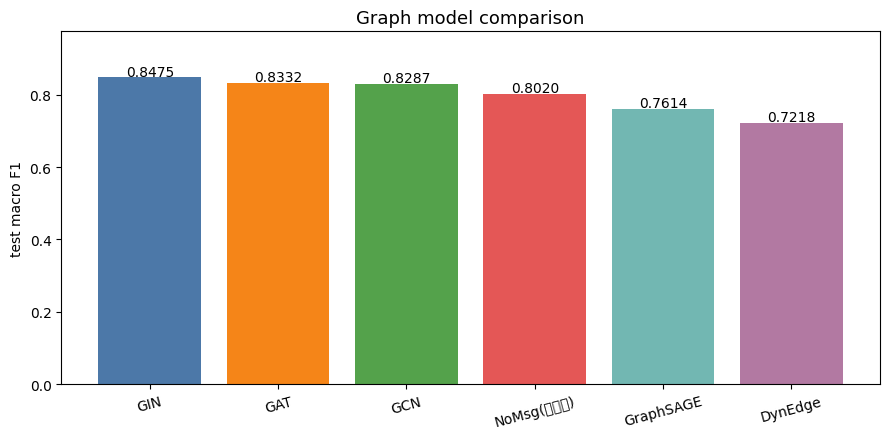

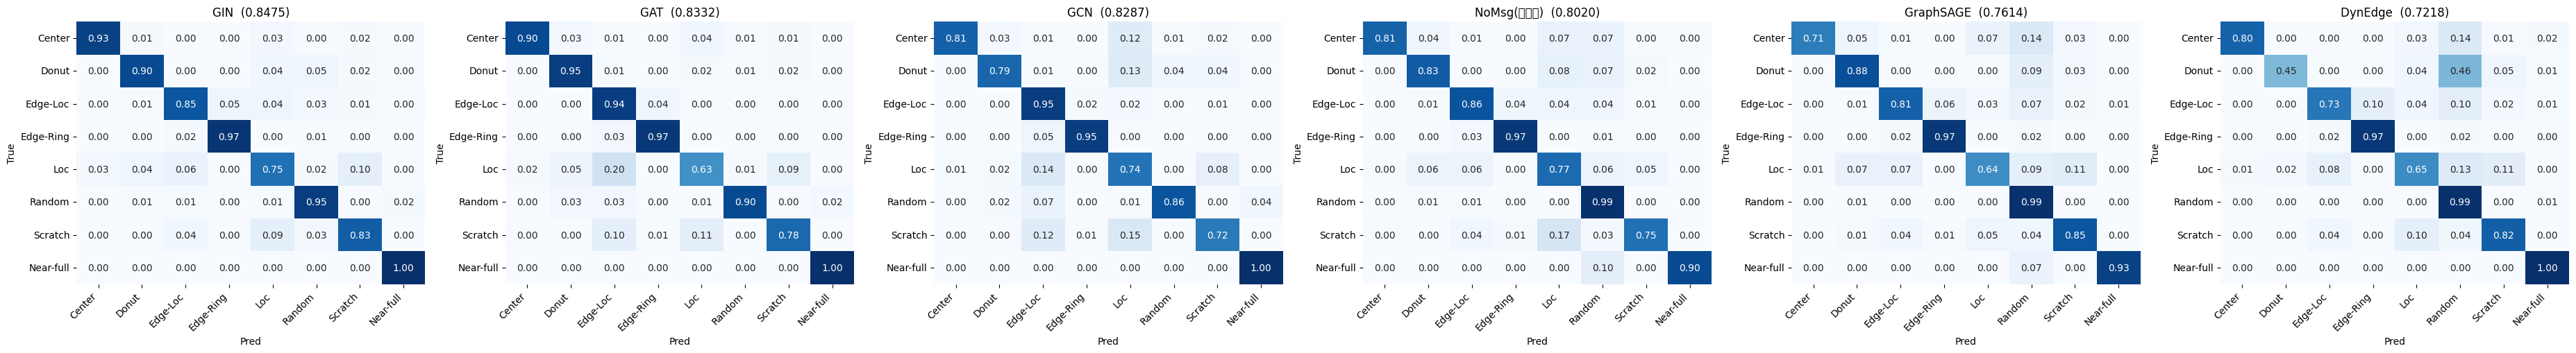

In [18]:
import seaborn as sns
names = [REVERSE_LABEL_MAP[i] for i in range(8)]
order = sorted(RESULTS.values(), key=lambda r: -r["test_macro_f1"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([r["name"] for r in order], [r["test_macro_f1"] for r in order],
       color=['#4C78A8','#F58518','#54A24B','#E45756','#72B7B2','#B279A2'][:len(order)])
for i, r in enumerate(order):
    ax.text(i, r["test_macro_f1"] + 0.005, f'{r["test_macro_f1"]:.4f}', ha='center', fontsize=10)
ax.set_ylabel('test macro F1'); ax.set_title('Graph model comparison', fontsize=13)
ax.set_ylim(0, max(r["test_macro_f1"] for r in order) * 1.15)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

n = len(order)
fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 5.2))
if n == 1:
    axes = [axes]
for ax, r in zip(axes, order):
    cm = r["confusion"]
    sns.heatmap(cm / np.maximum(cm.sum(axis=1, keepdims=True), 1), annot=True, fmt='.2f',
                cmap='Blues', vmin=0, vmax=1, xticklabels=names, yticklabels=names,
                ax=ax, cbar=False)
    ax.set_title(f'{r["name"]}  ({r["test_macro_f1"]:.4f})', fontsize=12)
    ax.set_ylabel('True'); ax.set_xlabel('Pred')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); plt.show()
